# NB_05_feature_analysis - 32-D Feature Analysis

**Purpose.** Quality-check the 32-dimensional feature space produced by the FeatureIntegrator: distributions, correlation with risk, PCA projections coloured by risk/town/day-night, and k-means clustering with cluster characterisation.

**Inputs.** labeled JSONLs under MIREIA/scenarios/*/dataset/dataset_labeled.jsonl (produced by NB_04 Step 9).

**Outputs.** diagnostic figures and CSV exports; identifies whether the modular feature vector is informative enough for the BDU-GRU.

**How to run.** Run top-to-bottom. The PCA and clustering cells are tunable via constants near the top of each section.

**Position in the workflow.** Diagnostic counterpart to NB_04. Useful before launching the BDU-GRU search (NB_04 Step 10).


In [14]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.max_columns", 120)

print("Libraries loaded.")

Libraries loaded.


In [15]:
try:
    from MIREIA.config import Config
    scenarios_root = Path(Config.PATH_TO_SCENARIOS)
except Exception:
    scenarios_root = Path("scenarios")

source_jsonl_name = "dataset_labeled.jsonl"
feature_vector_key = "feature_vector_32"

feature_names = [
    "num_objects",
    "bb_size_max", "bb_size_avg",
    "depth_min_norm", "depth_avg_norm",
    "size_change_max", "size_change_avg",
    "depth_change_max", "depth_change_avg",
    "bg_flow_x_norm", "bg_flow_y_norm",
    "left_threat_max", "left_threat_avg",
    "center_threat_max", "center_threat_avg",
    "right_threat_max", "right_threat_avg",
    "road_relative_size",
    "day_prob",
] + [f"climate_{i}" for i in range(1, 14)]

expected_feature_dim = len(feature_names)
feature_cols = feature_names.copy()

print(f"Feature dimensions: {expected_feature_dim}")
for i, name in enumerate(feature_names, 1):
    print(f"  {i:02d}. {name}")

Feature dimensions: 32
  01. num_objects
  02. bb_size_max
  03. bb_size_avg
  04. depth_min_norm
  05. depth_avg_norm
  06. size_change_max
  07. size_change_avg
  08. depth_change_max
  09. depth_change_avg
  10. bg_flow_x_norm
  11. bg_flow_y_norm
  12. left_threat_max
  13. left_threat_avg
  14. center_threat_max
  15. center_threat_avg
  16. right_threat_max
  17. right_threat_avg
  18. road_relative_size
  19. day_prob
  20. climate_1
  21. climate_2
  22. climate_3
  23. climate_4
  24. climate_5
  25. climate_6
  26. climate_7
  27. climate_8
  28. climate_9
  29. climate_10
  30. climate_11
  31. climate_12
  32. climate_13


## Data Loading

Discovers all `dataset_labeled.jsonl` files under the scenarios root and builds a single flat DataFrame.

In [16]:
if not scenarios_root.exists():
    raise FileNotFoundError(f"Scenarios root not found: {scenarios_root}")

scenario_dirs = [
    p for p in sorted(scenarios_root.iterdir())
    if p.is_dir() and p.name not in {"videos", "__pycache__"}
]
jsonl_paths = [p / source_jsonl_name for p in scenario_dirs if (p / source_jsonl_name).is_file()]

if not jsonl_paths:
    raise RuntimeError(f"No {source_jsonl_name} files found under {scenarios_root}")

print(f"Found {len(jsonl_paths)} labeled JSONL files.")

rows = []
for path in jsonl_paths:
    scenario_name = path.parent.name
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            env = rec.get("environment", {}) if isinstance(rec.get("environment"), dict) else {}
            ego = rec.get("ego", {}) if isinstance(rec.get("ego"), dict) else {}

            vec = rec.get(feature_vector_key)
            if isinstance(vec, (list, tuple)) and len(vec) == expected_feature_dim:
                feat = [float(v) for v in vec]
                has_feature = 1
            else:
                feat = [np.nan] * expected_feature_dim
                has_feature = 0

            row = {
                "scenario": scenario_name,
                "frame_id": rec.get("frame_id", np.nan),
                "ground_truth_risk": rec.get("ground_truth_risk", np.nan),
                "predicted_risk": rec.get("predicted_risk", np.nan),
                "true_ego_speed": rec.get("true_ego_speed", ego.get("speed", np.nan)),
                "day_night": env.get("day_night", rec.get("day_night")),
                "weather": env.get("weather", env.get("climate", rec.get("weather"))),
                "has_feature_vector": has_feature,
            }
            for i, value in enumerate(feat):
                row[feature_names[i]] = value
            rows.append(row)

if not rows:
    raise RuntimeError("No valid records were loaded.")

df = pd.DataFrame(rows)
for col in ["frame_id", "ground_truth_risk", "predicted_risk", "true_ego_speed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Total records:      {len(df):,}")
print(f"Scenarios:          {df['scenario'].nunique():,}")
print(f"With feature vector: {int(df['has_feature_vector'].sum()):,}")

Found 84 labeled JSONL files.
Total records:      302,400
Scenarios:          84
With feature vector: 302,400


In [17]:
# Basic overview and quality checks

def _safe_nunique(series: pd.Series) -> int:
    try:
        return int(series.nunique(dropna=True))
    except TypeError:
        # Handle unhashable values (e.g., dict/list) by stringifying before counting
        return int(series.astype(str).nunique(dropna=True))

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.apply(_safe_nunique),
})

print("DataFrame shape:", df.shape)
print("\nTop scenarios by record count:")
print(df["scenario"].value_counts().head(10))

print("\nMissingness overview (first 20 columns):")
display(overview.head(20))

print("\nNumeric summary:")
display(df[["ground_truth_risk", "predicted_risk", "true_ego_speed"] + feature_cols].describe().T.head(15))

display(df.head(5))

DataFrame shape: (302400, 40)

Top scenarios by record count:
scenario
01A_ClearNoon_Town01_HighVol     3600
01B_ClearNoon_Town01_LowVol      3600
01C_ClearNoon_Town02_HighVol     3600
01D_ClearNoon_Town02_LowVol      3600
02A_CloudyNoon_Town03_HighVol    3600
02B_CloudyNoon_Town03_LowVol     3600
02C_CloudyNoon_Town03_HighVol    3600
02D_CloudyNoon_Town04_LowVol     3600
03A_WetNoon_Town04_HighVol       3600
03B_WetNoon_Town04_LowVol        3600
Name: count, dtype: int64

Missingness overview (first 20 columns):


,dtype,missing_pct,unique
scenario,str,0.0,84
frame_id,int64,0.0,3600
ground_truth_risk,float64,0.0,266431
predicted_risk,float64,100.0,0
true_ego_speed,float64,0.0,68679
day_night,object,100.0,0
weather,object,0.0,22
has_feature_vector,int64,0.0,1
num_objects,float64,0.0,15
bb_size_max,float64,0.0,217593



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
ground_truth_risk,302400.0,3.168218,2.971118,0.034843,1.549834e+00,2.219959,3.654122,39.295417
predicted_risk,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_ego_speed,302400.0,5.339354,6.756625,0.000000,2.408903e-09,3.325708,8.037802,24.456907
num_objects,302400.0,2.113717,2.068474,0.000000,0.000000e+00,2.000000,3.000000,14.000000
bb_size_max,302400.0,0.086348,0.095484,0.000000,0.000000e+00,0.058703,0.140523,0.697561
bb_size_avg,302400.0,0.059787,0.066141,0.000000,0.000000e+00,0.042287,0.087179,0.697561
depth_min_norm,302400.0,0.282771,0.443284,0.000015,5.498359e-03,0.009200,1.000000,1.000000
depth_avg_norm,302400.0,0.009353,0.015619,0.000000,0.000000e+00,0.008633,0.013420,1.000000
size_change_max,302400.0,0.748742,0.466981,0.000000,0.000000e+00,1.003034,1.031120,4.015167
size_change_avg,302400.0,0.730583,0.453485,0.000000,0.000000e+00,0.995723,1.009627,3.058724


,scenario,frame_id,ground_truth_risk,predicted_risk,true_ego_speed,day_night,weather,has_feature_vector,num_objects,bb_size_max,bb_size_avg,depth_min_norm,depth_avg_norm,size_change_max,size_change_avg,depth_change_max,depth_change_avg,bg_flow_x_norm,bg_flow_y_norm,left_threat_max,left_threat_avg,center_threat_max,center_threat_avg,right_threat_max,right_threat_avg,road_relative_size,day_prob,climate_1,climate_2,climate_3,climate_4,climate_5,climate_6,climate_7,climate_8,climate_9,climate_10,climate_11,climate_12,climate_13
0,01A_ClearNoon_Town01_HighVol,0,4.682484,NaN,7.874935,None,ClearNoon,1,2.0,0.060099,0.043675,0.003241,0.005667,1.000001,1.000000,0.999999,0.999998,0.000000,0.000000,0.0,0.0,3.085033,2.160293,0.0,0.0,0.137772,0.996484,0.989570,0.000260,0.000036,0.000014,0.000186,0.000005,0.000087,0.000437,0.000023,0.009227,0.000156,0.0,0.0
1,01A_ClearNoon_Town01_HighVol,1,4.697520,NaN,7.791110,None,ClearNoon,1,2.0,0.058856,0.043304,0.004027,0.006495,1.037288,0.998162,1.242200,1.174860,0.000185,0.000014,0.0,0.0,2.579535,1.827205,0.0,0.0,0.148300,0.997826,0.986546,0.000250,0.000029,0.000011,0.000145,0.000004,0.000079,0.000355,0.000019,0.012412,0.000150,0.0,0.0
2,01A_ClearNoon_Town01_HighVol,2,4.731431,NaN,7.794961,None,ClearNoon,1,2.0,0.063058,0.046356,0.003742,0.006614,1.159142,1.141613,1.053768,1.010443,-0.000016,-0.000011,0.0,0.0,3.005979,2.117209,0.0,0.0,0.161743,0.997953,0.969716,0.000400,0.000036,0.000016,0.000185,0.000005,0.000115,0.000476,0.000026,0.028807,0.000217,0.0,0.0
3,01A_ClearNoon_Town01_HighVol,3,4.766882,NaN,7.815786,None,ClearNoon,1,2.0,0.067992,0.049425,0.003582,0.006443,1.110168,1.074126,0.982283,0.969736,-0.000027,0.000096,0.0,0.0,2.899189,2.050394,0.0,0.0,0.167404,0.998099,0.975810,0.000333,0.000030,0.000013,0.000154,0.000004,0.000090,0.000400,0.000022,0.022970,0.000173,0.0,0.0
4,01A_ClearNoon_Town01_HighVol,4,4.817879,NaN,7.911495,None,ClearNoon,1,2.0,0.072558,0.052257,0.003841,0.007321,1.103613,1.079633,1.157721,1.117288,-0.000044,0.000139,0.0,0.0,2.749747,1.889194,0.0,0.0,0.178513,0.997122,0.967602,0.000475,0.000044,0.000020,0.000217,0.000007,0.000134,0.000568,0.000033,0.030649,0.000252,0.0,0.0


## Univariate Analysis
Distribution-level analysis for target, speed, and high-variance feature dimensions.

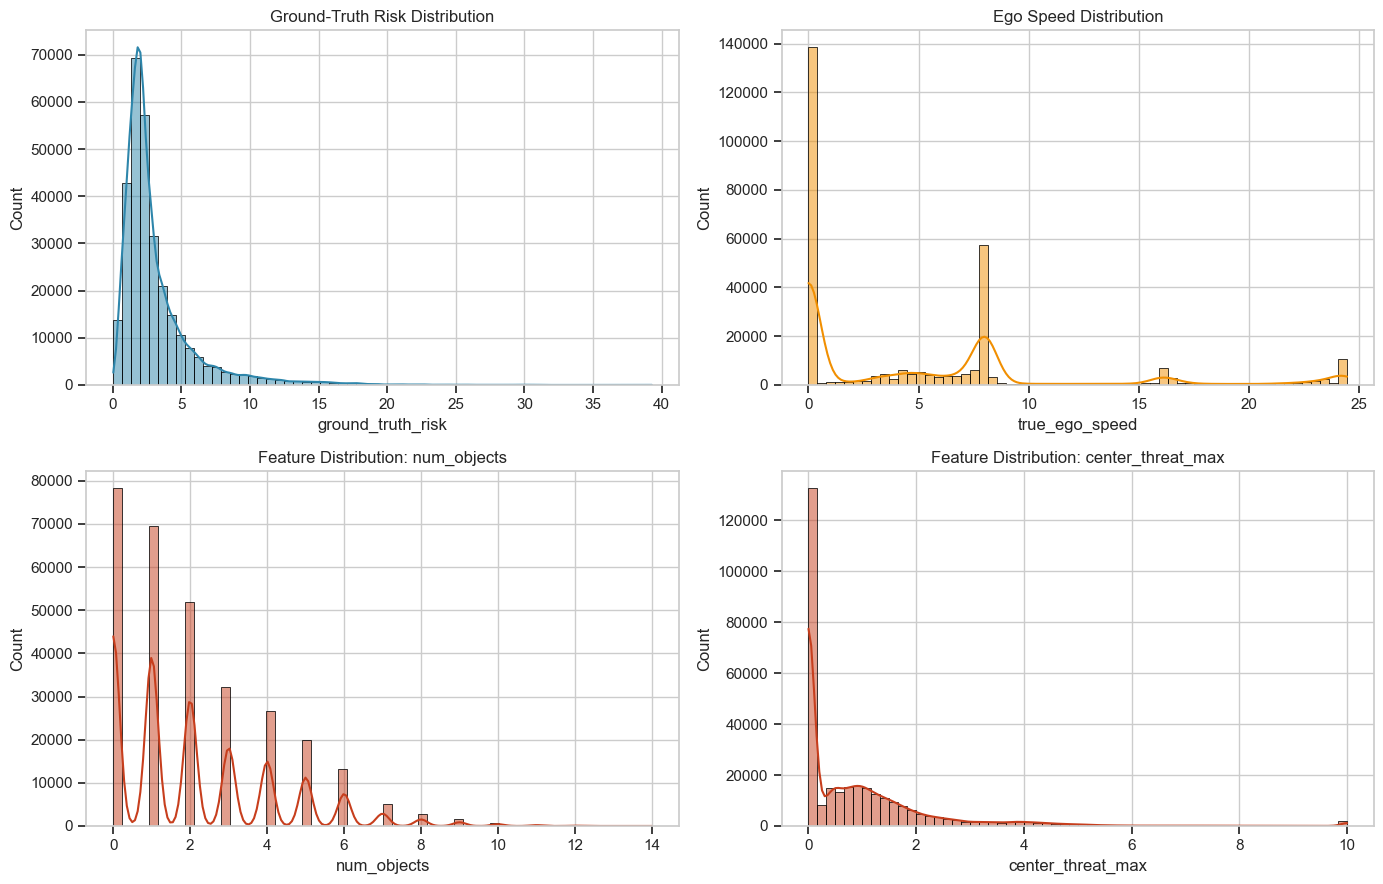

Top 10 most variable feature dimensions:
num_objects          4.278584
center_threat_max    2.032143
center_threat_avg    1.367250
left_threat_max      0.815637
right_threat_max     0.531601
left_threat_avg      0.433126
right_threat_avg     0.398095
size_change_max      0.218071
depth_change_max     0.217733
size_change_avg      0.205649
dtype: float64


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df["ground_truth_risk"], kde=True, bins=60, ax=axes[0, 0], color="#2E86AB")
axes[0, 0].set_title("Ground-Truth Risk Distribution")

sns.histplot(df["true_ego_speed"], kde=True, bins=60, ax=axes[0, 1], color="#F18F01")
axes[0, 1].set_title("Ego Speed Distribution")

# Highest-variance feature dimensions for quick inspection
feature_var = df[feature_cols].var(numeric_only=True).sort_values(ascending=False)
top_feat = feature_var.head(2).index.tolist()

for k, feat in enumerate(top_feat):
    r = 1
    c = k
    sns.histplot(df[feat], kde=True, bins=60, ax=axes[r, c], color="#C73E1D")
    axes[r, c].set_title(f"Feature Distribution: {feat}")

plt.tight_layout()
plt.show()

print("Top 10 most variable feature dimensions:")
print(feature_var.head(10))

## Matrix Analyses
Correlation and covariance structures for the feature vector and target variables.

Top correlated features with ground_truth_risk:


,pearson,spearman
climate_5,0.212970,0.231083
climate_7,0.205049,0.116350
climate_10,-0.139023,-0.154335
climate_6,0.134428,0.041862
climate_1,-0.117074,-0.140286
right_threat_max,-0.112670,-0.103473
right_threat_avg,-0.110704,-0.102986
num_objects,-0.103642,-0.057307
climate_8,-0.079729,-0.064139
climate_3,-0.075250,-0.013626


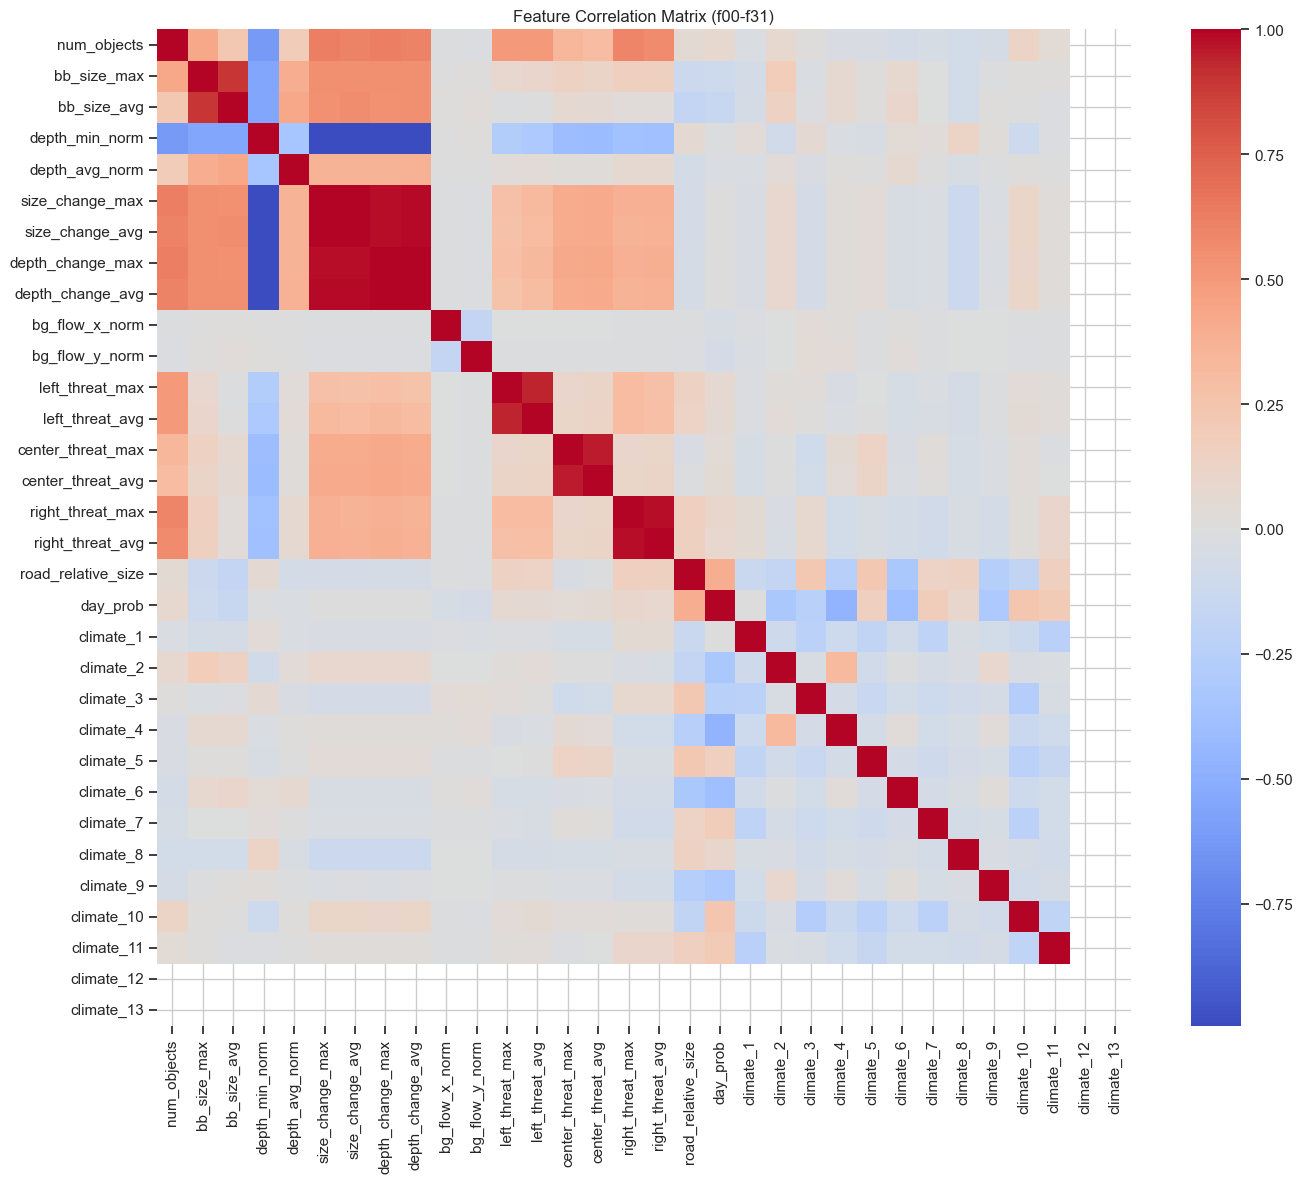

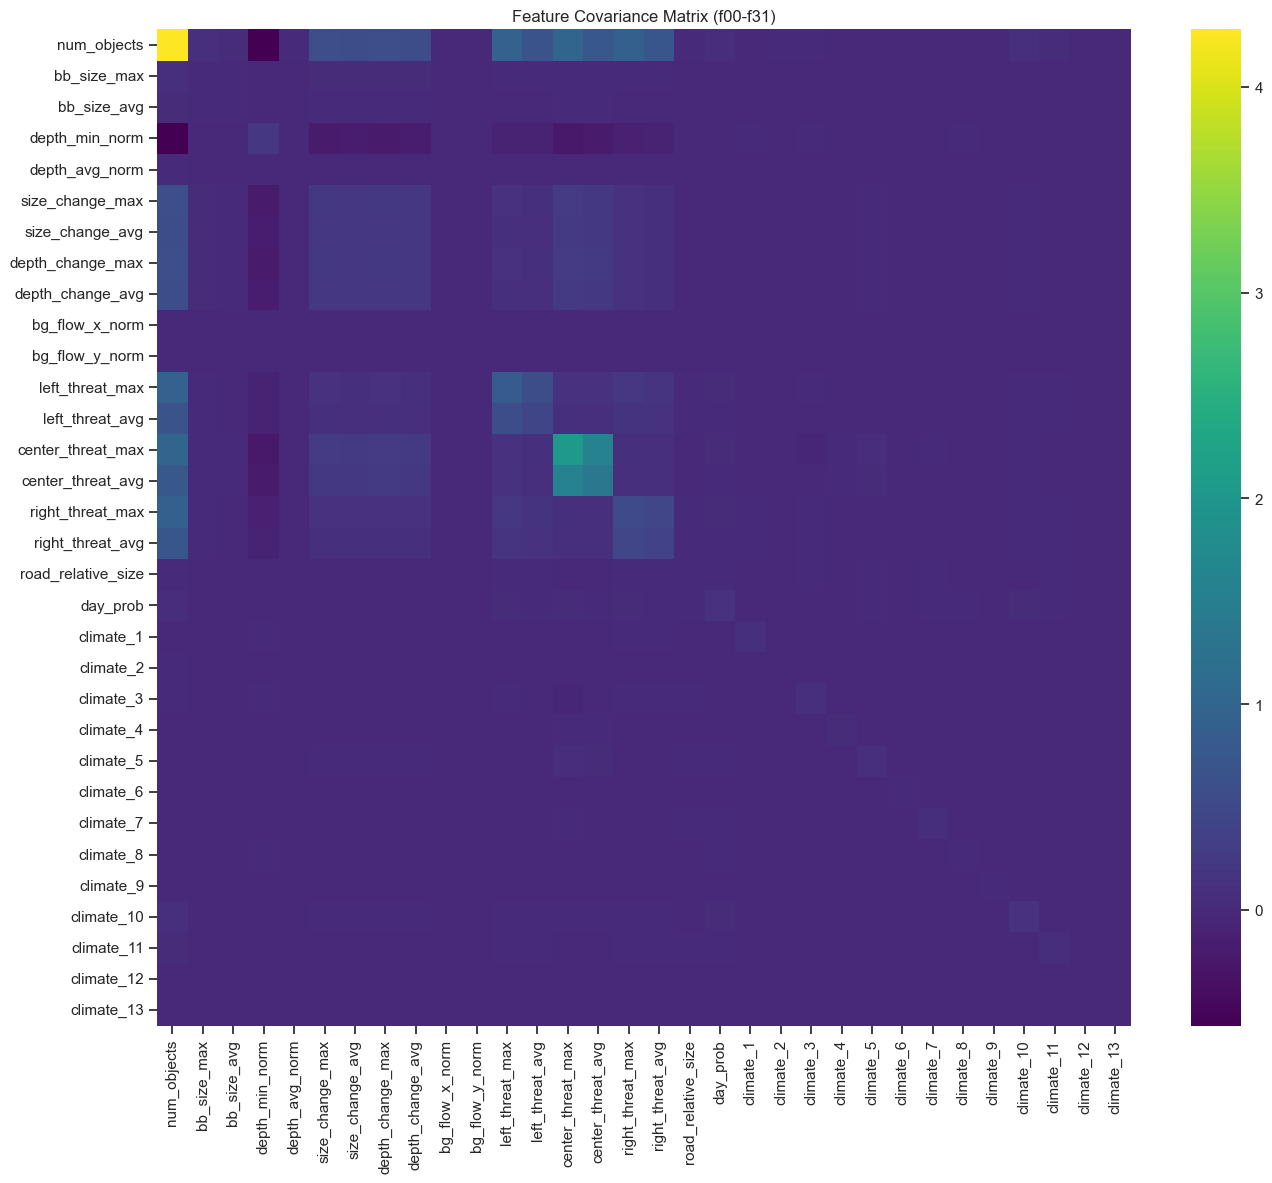

In [19]:
# Correlation with target (Pearson and Spearman)
pearson_target = df[feature_cols + ["ground_truth_risk"]].corr(method="pearson")["ground_truth_risk"].drop("ground_truth_risk")
spearman_target = df[feature_cols + ["ground_truth_risk"]].corr(method="spearman")["ground_truth_risk"].drop("ground_truth_risk")

corr_table = pd.DataFrame({
    "pearson": pearson_target,
    "spearman": spearman_target,
}).sort_values("pearson", key=lambda s: s.abs(), ascending=False)

print("Top correlated features with ground_truth_risk:")
display(corr_table.head(15))

# Full feature correlation matrix
corr_feat = df[feature_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_feat, cmap="coolwarm", center=0.0)
plt.title("Feature Correlation Matrix (f00-f31)")
plt.tight_layout()
plt.show()

# Covariance matrix
cov_feat = df[feature_cols].cov()
plt.figure(figsize=(14, 12))
sns.heatmap(cov_feat, cmap="viridis")
plt.title("Feature Covariance Matrix (f00-f31)")
plt.tight_layout()
plt.show()

## Pairwise Matrix Plot (Sampled)
A compact pairwise view on risk plus top correlated feature dimensions.

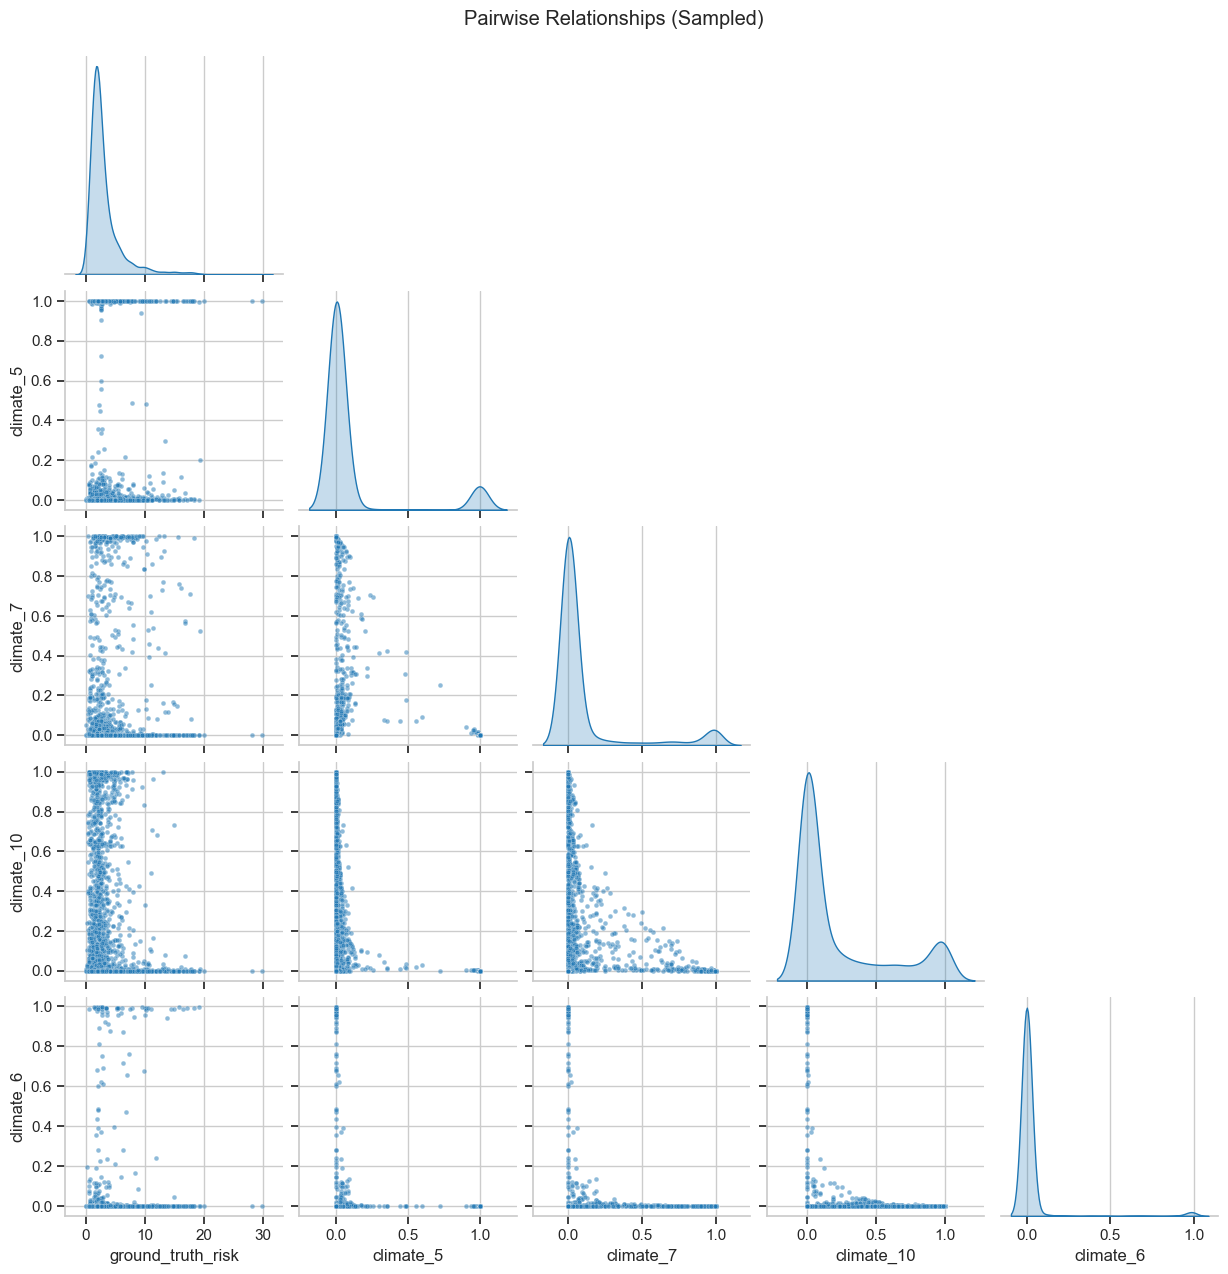

In [20]:
top_pair_features = corr_table.head(4).index.tolist()
pair_cols = ["ground_truth_risk"] + top_pair_features

pair_df = df[pair_cols].copy().dropna()
max_pair_rows = 2500
if len(pair_df) > max_pair_rows:
    pair_df = pair_df.sample(max_pair_rows, random_state=42)

sns.pairplot(pair_df, corner=True, diag_kind="kde", plot_kws={"s": 12, "alpha": 0.5})
plt.suptitle("Pairwise Relationships (Sampled)", y=1.02)
plt.show()

## PCA Analysis
2D and 3D PCA projections on standardized feature vectors, first colored by target risk and then by loaded town label (e.g., TOWN01).

In [35]:
X = df[feature_cols].copy()
y = pd.to_numeric(df["ground_truth_risk"], errors="coerce")

valid_target = y.notna()
X = X.loc[valid_target]
y = y.loc[valid_target]

scenario_for_pca = df.loc[valid_target, "scenario"].astype(str)
town_labels = (
    scenario_for_pca
    .str.extract(r"(Town\d+)", expand=False)
    .str.upper()
    .fillna("UNKNOWN")
)

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

max_points_3d = 6000
rng = np.random.default_rng(42)
idx = rng.choice(len(X_pca3), size=min(max_points_3d, len(X_pca3)), replace=False)

print("2D PCA explained variance:", np.round(pca2.explained_variance_ratio_, 4), "| cumulative:", float(np.sum(pca2.explained_variance_ratio_)))
print("3D PCA explained variance:", np.round(pca3.explained_variance_ratio_, 4), "| cumulative:", float(np.sum(pca3.explained_variance_ratio_)))

2D PCA explained variance: [0.2464 0.0958] | cumulative: 0.34214783887153255
3D PCA explained variance: [0.2464 0.0958 0.0685] | cumulative: 0.41062156582963233


### PCA Colored by Risk

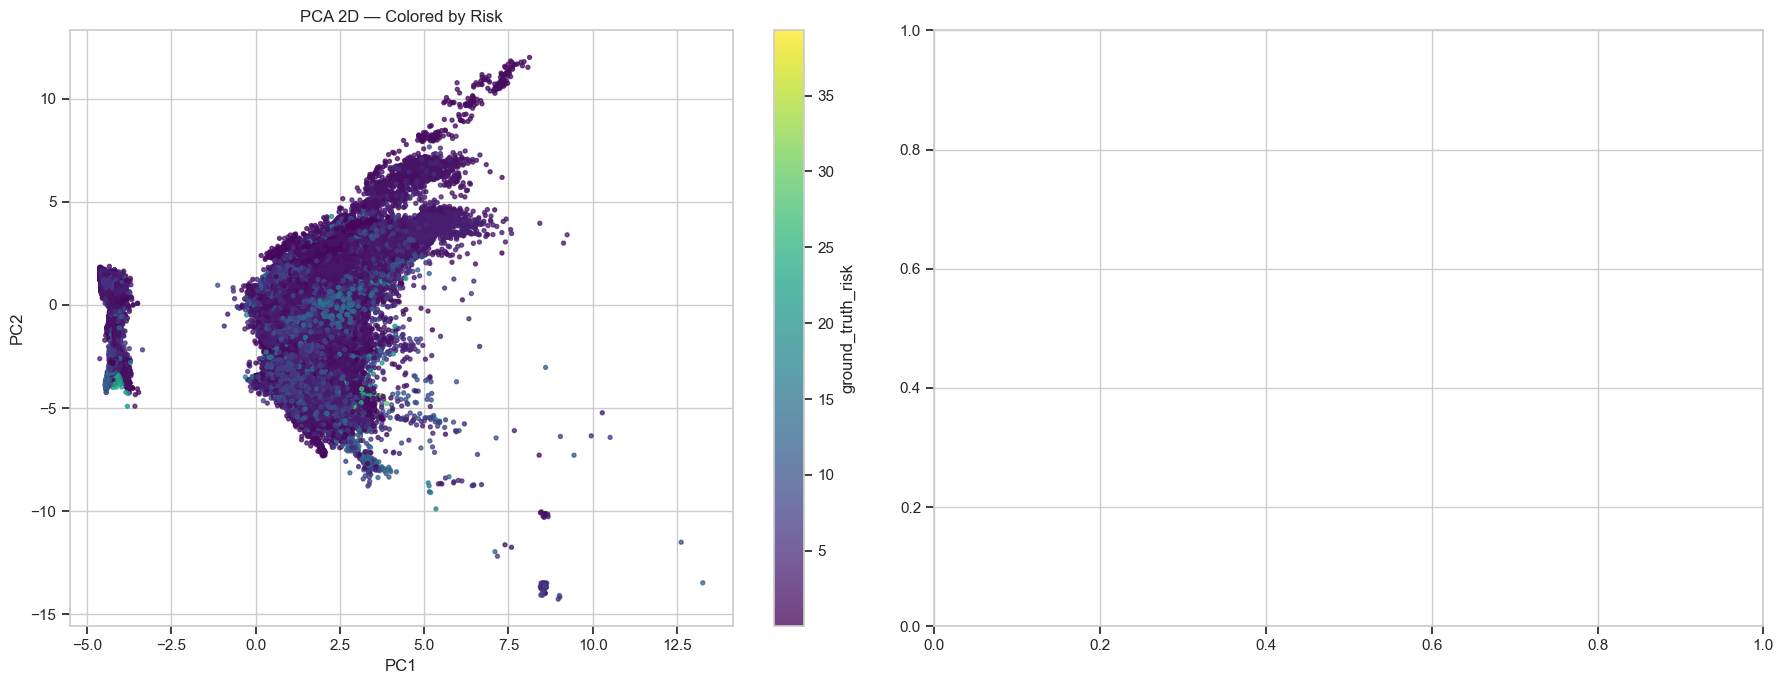

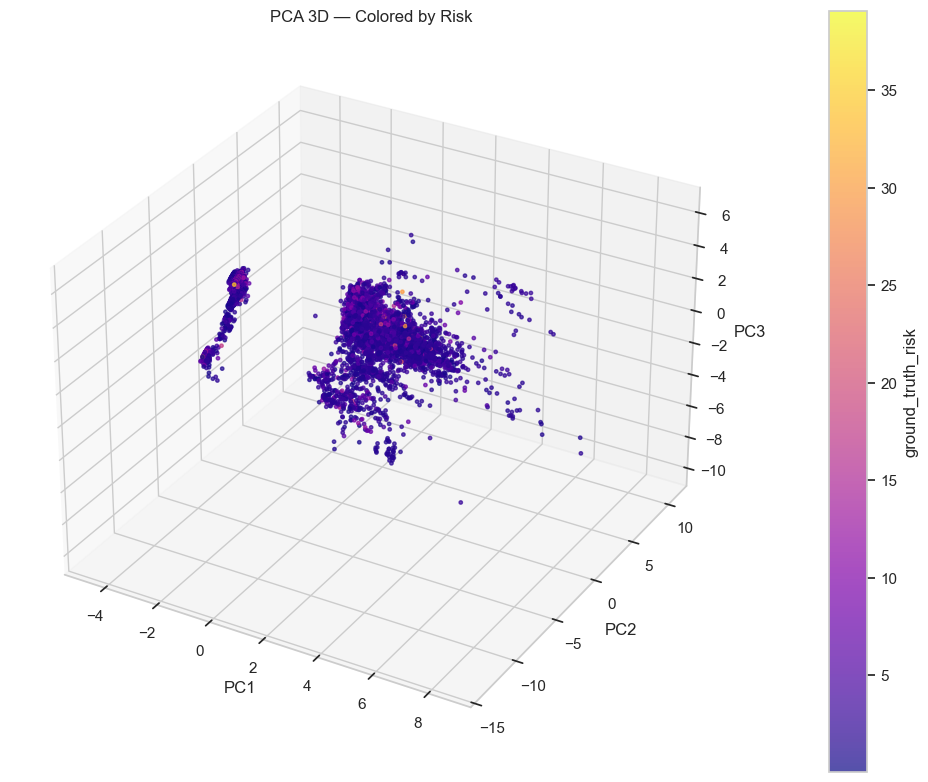

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 2D
sc2 = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y.values, cmap="viridis", s=8, alpha=0.75)
fig.colorbar(sc2, ax=axes[0], label="ground_truth_risk")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA 2D — Colored by Risk")

plt.tight_layout()
plt.show()

# 3D
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection="3d")
pts = ax3d.scatter(X_pca3[idx, 0], X_pca3[idx, 1], X_pca3[idx, 2], c=y.values[idx], cmap="plasma", s=6, alpha=0.7)
fig3d.colorbar(pts, ax=ax3d, pad=0.1, label="ground_truth_risk")
ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
ax3d.set_title("PCA 3D — Colored by Risk")
plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x24dccbe0d10>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

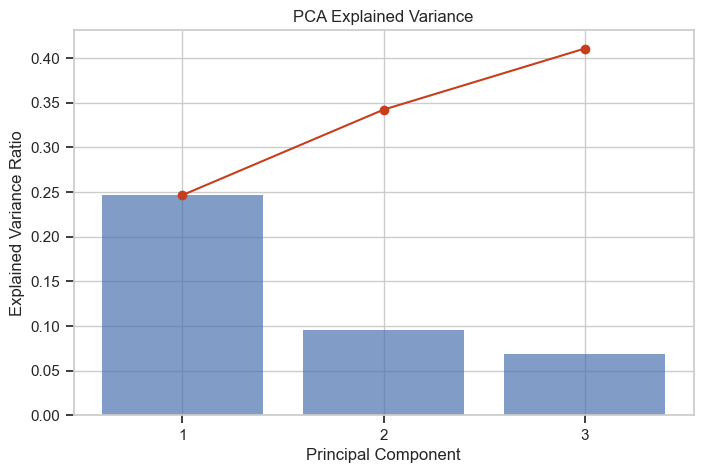

In [37]:
# Plot explained variance
plt.figure(figsize=(8, 5))
components = np.arange(1, len(pca3.explained_variance_ratio_) + 1)
plt.bar(components, pca3.explained_variance_ratio_, alpha=0.7, color="#4C72B0")
plt.plot(components, np.cumsum(pca3.explained_variance_ratio_), marker="o", color="#C73E1D")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.xticks(components)

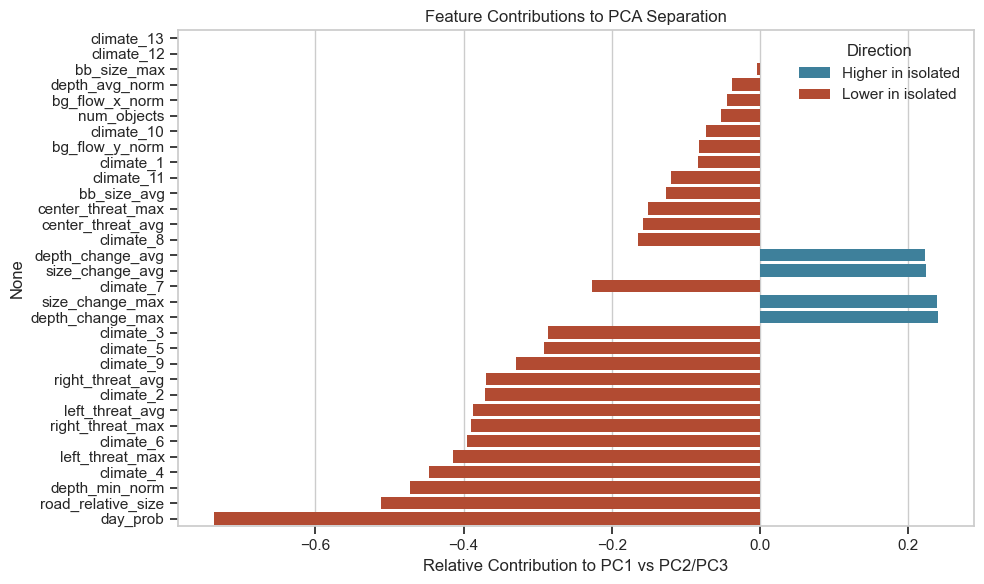

In [46]:
# Contribution of original features to the first 3 PCs
loadings = pd.DataFrame(pca3.components_.T, columns=[f"PC{i+1}" for i in range(3)], index=feature_cols)
loadings["z_diff"] = loadings["PC1"] - loadings["PC2"].abs() - loadings["PC3"].abs()
feature_diff = loadings.sort_values("z_diff", key=lambda s: s.abs(), ascending=False)

# Plot strongest differences for each feature
plt.figure(figsize=(10, 6))
plot_diff = feature_diff.head(32).iloc[::-1].copy()
plot_diff["direction"] = np.where(plot_diff["z_diff"] >= 0, "Higher in isolated", "Lower in isolated")
sns.barplot(x="z_diff", y=plot_diff.index, hue="direction", data=plot_diff, dodge=False, palette={"Higher in isolated": "#2E86AB", "Lower in isolated": "#C73E1D"})
plt.xlabel("Relative Contribution to PC1 vs PC2/PC3")
plt.title("Feature Contributions to PCA Separation")
plt.legend(title="Direction")
plt.tight_layout()
plt.show()

### PCA Colored by Town

Towns: ['TOWN01', 'TOWN02', 'TOWN03', 'TOWN04', 'TOWN05', 'TOWN10']


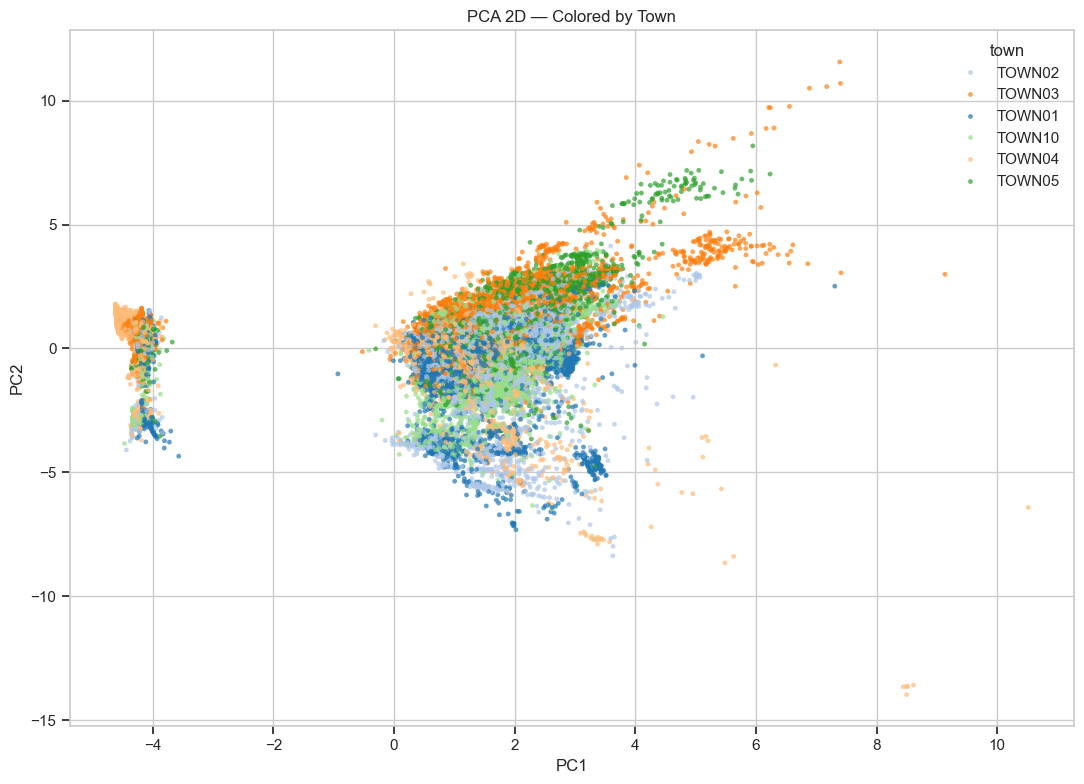

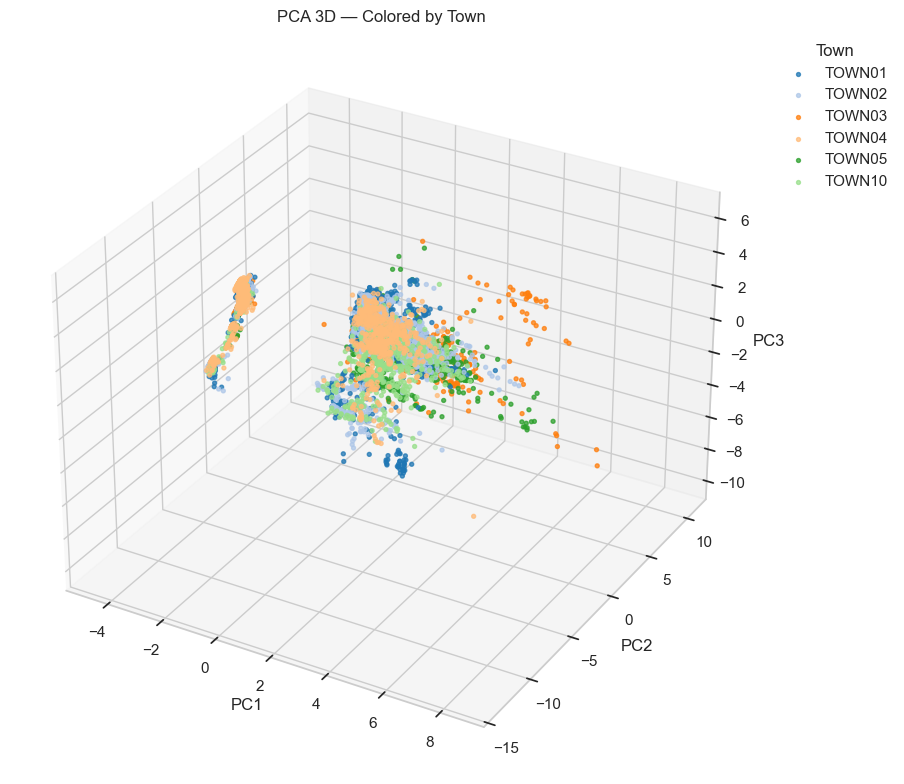

In [38]:
town_values = town_labels.values
town_unique = sorted(pd.unique(town_values))
palette = dict(zip(town_unique, sns.color_palette("tab20", n_colors=len(town_unique))))
print("Towns:", town_unique)

# 2D
plot_df_town = pd.DataFrame({"PC1": X_pca2[:, 0], "PC2": X_pca2[:, 1], "town": town_values})
if len(plot_df_town) > 30000:
    plot_df_town = plot_df_town.sample(30000, random_state=42)

plt.figure(figsize=(11, 8))
sns.scatterplot(data=plot_df_town, x="PC1", y="PC2", hue="town", palette=palette, s=12, alpha=0.7, linewidth=0)
plt.title("PCA 2D — Colored by Town")
plt.tight_layout()
plt.show()

# 3D
town_color_map = dict(zip(town_unique, sns.color_palette("tab20", n_colors=len(town_unique))))
town_sample = town_values[idx]
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
for town in town_unique:
    mask = town_sample == town
    if not np.any(mask):
        continue
    ax.scatter(X_pca3[idx, 0][mask], X_pca3[idx, 1][mask], X_pca3[idx, 2][mask], color=town_color_map[town], label=town, s=8, alpha=0.75)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("PCA 3D — Colored by Town")
ax.legend(title="Town", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### PCA Colored by Day/Night Probability

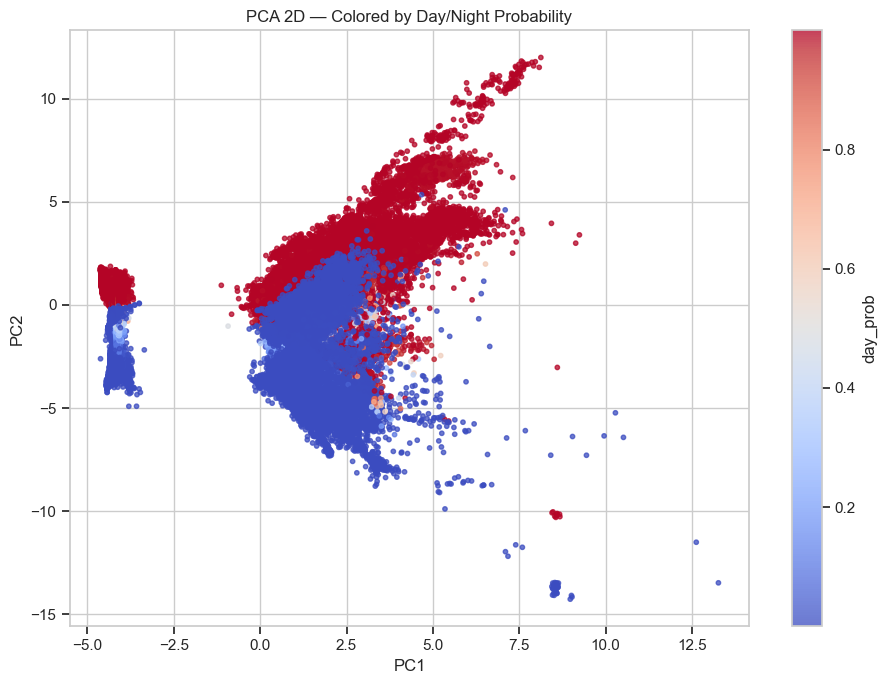

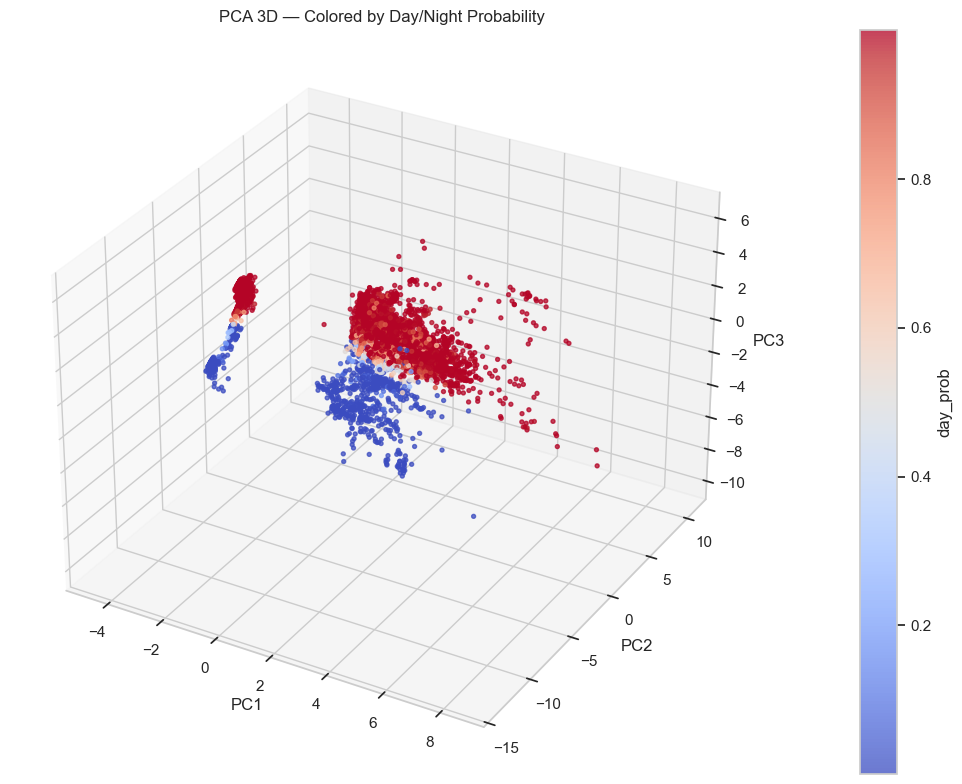

In [39]:
day_prob_series = pd.to_numeric(df.loc[valid_target, "day_prob"], errors="coerce")
day_prob_plot = day_prob_series.fillna(day_prob_series.median()) if day_prob_series.notna().any() else pd.Series(np.zeros(len(day_prob_series)), index=day_prob_series.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=day_prob_plot.values, cmap="coolwarm", s=10, alpha=0.75)
fig.colorbar(sc, ax=axes[0], label="day_prob")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("PCA 2D — Colored by Day/Night Probability")

fig.delaxes(axes[1])
plt.tight_layout()
plt.show()

# 3D
fig3d = plt.figure(figsize=(11, 8))
ax3d = fig3d.add_subplot(111, projection="3d")
pts = ax3d.scatter(X_pca3[idx, 0], X_pca3[idx, 1], X_pca3[idx, 2], c=day_prob_plot.values[idx], cmap="coolwarm", s=8, alpha=0.75)
fig3d.colorbar(pts, ax=ax3d, pad=0.1, label="day_prob")
ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
ax3d.set_title("PCA 3D — Colored by Day/Night Probability")
plt.tight_layout()
plt.show()

### PCA Colored by Speed

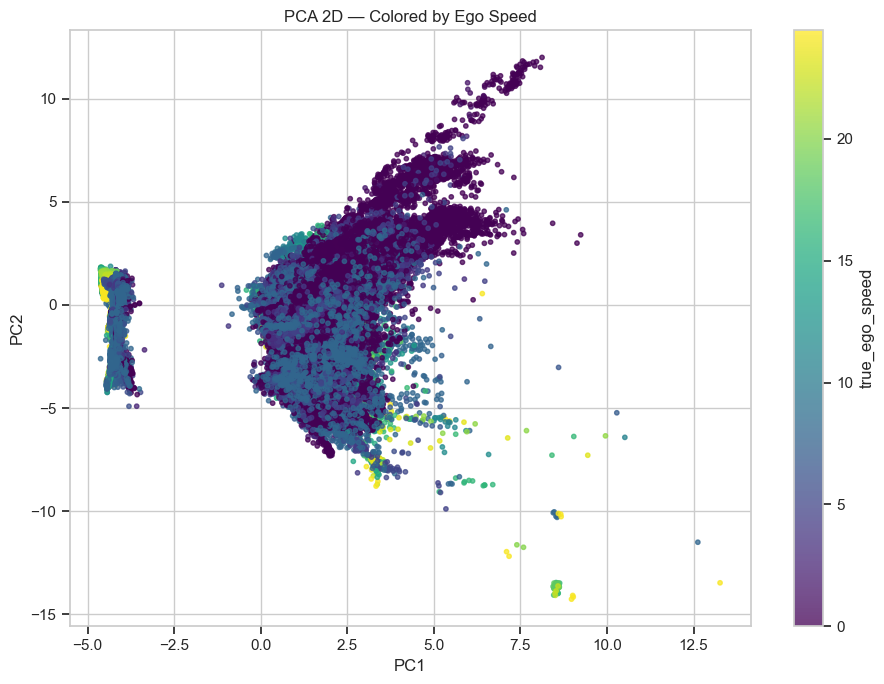

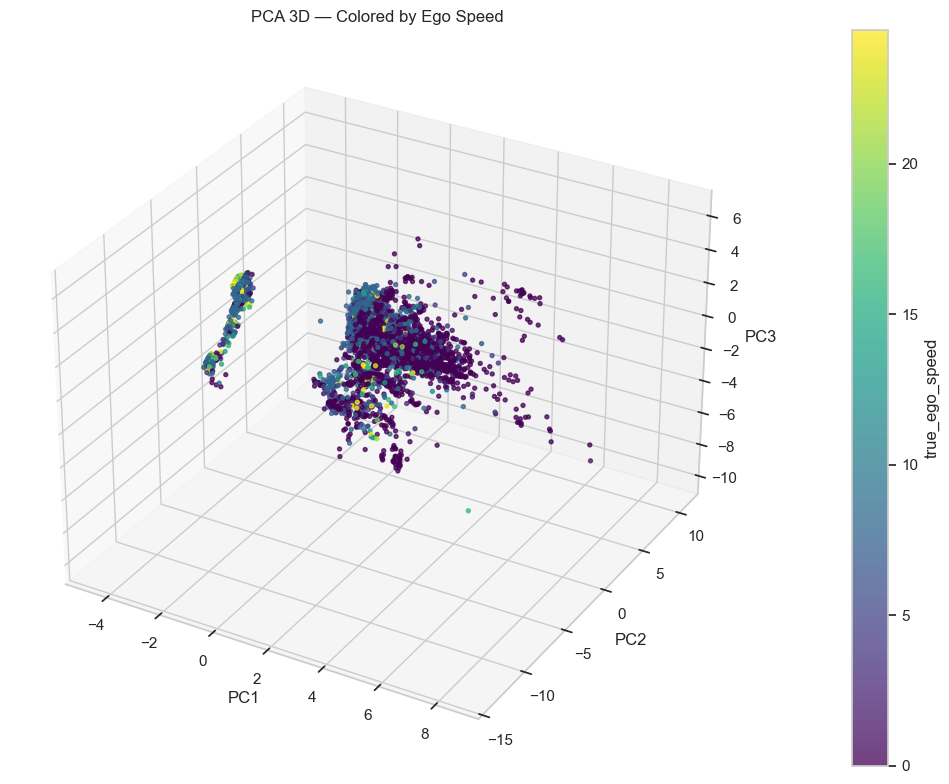

In [40]:
speed_series = pd.to_numeric(df.loc[valid_target, "true_ego_speed"], errors="coerce")
speed_plot = speed_series.fillna(speed_series.median()) if speed_series.notna().any() else pd.Series(np.zeros(len(speed_series)), index=speed_series.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=speed_plot.values, cmap="viridis", s=10, alpha=0.75)
fig.colorbar(sc, ax=axes[0], label="true_ego_speed")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("PCA 2D — Colored by Ego Speed")

fig.delaxes(axes[1])
plt.tight_layout()
plt.show()

# 3D
fig3d = plt.figure(figsize=(11, 8))
ax3d = fig3d.add_subplot(111, projection="3d")
pts = ax3d.scatter(X_pca3[idx, 0], X_pca3[idx, 1], X_pca3[idx, 2], c=speed_plot.values[idx], cmap="viridis", s=8, alpha=0.75)
fig3d.colorbar(pts, ax=ax3d, pad=0.1, label="true_ego_speed")
ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
ax3d.set_title("PCA 3D — Colored by Ego Speed")
plt.tight_layout()
plt.show()

### Isolated Group (PC1 < −2, PC2 > −5)

Visual diagnostics for the unusual cluster that appears isolated in PCA space.

Isolated group size: 83,527 / 302,400 (27.62%)
Mean day_prob isolated: 0.8211  |  rest: 0.8265


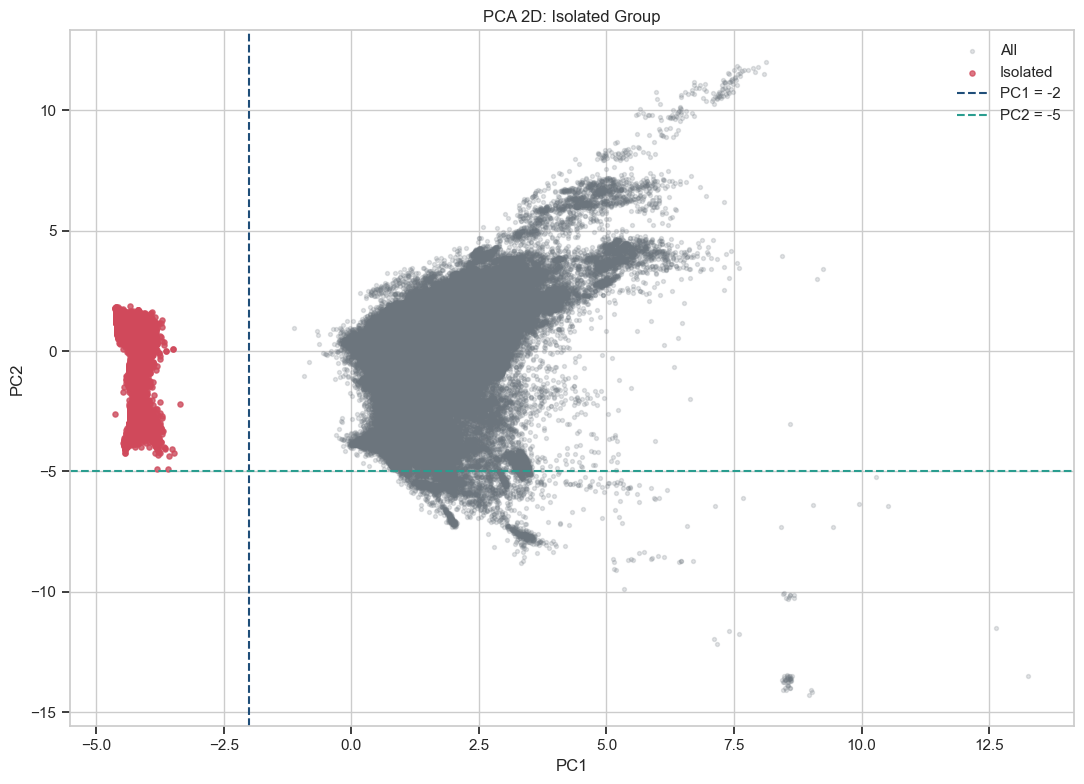


Top towns:     {'TOWN04': 28709, 'TOWN03': 21874, 'TOWN01': 9905, 'TOWN02': 9234, 'TOWN05': 8087, 'TOWN10': 5718}
Top scenarios: {'06D_MidRainyNoon_Town04_LowVol': 2492, '02D_CloudyNoon_Town04_LowVol': 2467, '03D_WetNoon_Town04_LowVol': 2414, '09D_CloudySunset_Town04_LowVol': 2388, '12D_SoftRainSunset_Town04_LowVol': 2312, '15A_ClearNoon_Town04_HighVol_NoFog_Night': 2245}


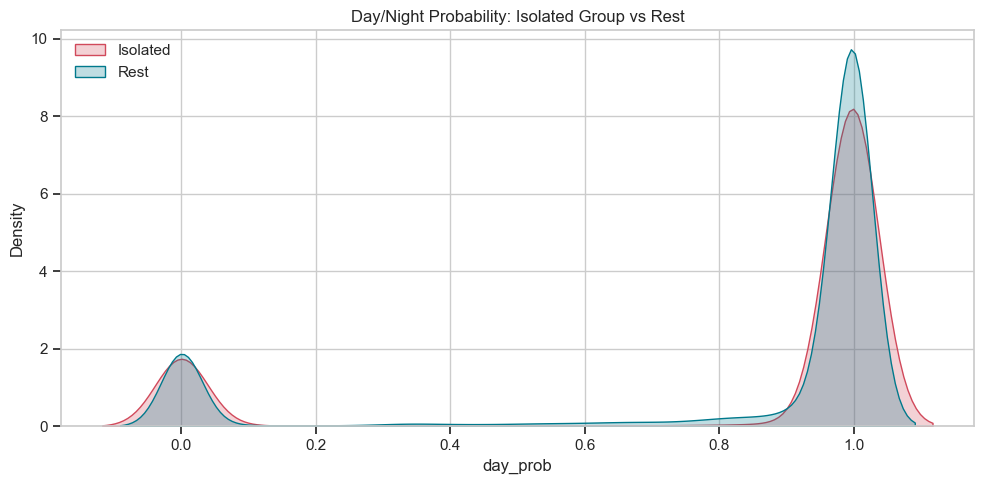

In [41]:
left_mask = (X_pca2[:, 0] < -2.0) & (X_pca2[:, 1] > -5.0)

town_series = pd.Series(town_labels).reset_index(drop=True)
scenario_series = pd.Series(scenario_for_pca).reset_index(drop=True)

left_day_mean = float(np.nanmean(day_prob_plot.values[left_mask])) if np.any(left_mask) else float("nan")
rest_day_mean = float(np.nanmean(day_prob_plot.values[~left_mask])) if np.any(~left_mask) else float("nan")

print(f"Isolated group size: {int(left_mask.sum()):,} / {len(left_mask):,} ({100.0 * left_mask.mean():.2f}%)")
print(f"Mean day_prob isolated: {left_day_mean:.4f}  |  rest: {rest_day_mean:.4f}")

plt.figure(figsize=(11, 8))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], s=8, alpha=0.20, color="#6c757d", label="All")
if np.any(left_mask):
    plt.scatter(X_pca2[left_mask, 0], X_pca2[left_mask, 1], s=14, alpha=0.75, color="#d1495b", label="Isolated")
plt.axvline(-2.0, color="#1f4e79", linestyle="--", linewidth=1.5, label="PC1 = -2")
plt.axhline(-5.0, color="#2a9d8f", linestyle="--", linewidth=1.5, label="PC2 = -5")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA 2D: Isolated Group")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop towns:    ", town_series[left_mask].value_counts().head(6).to_dict())
print("Top scenarios:", scenario_series[left_mask].value_counts().head(6).to_dict())

if np.any(left_mask) and np.any(~left_mask):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(day_prob_plot.values[left_mask], fill=True, label="Isolated", color="#d1495b")
    sns.kdeplot(day_prob_plot.values[~left_mask], fill=True, label="Rest", color="#00798c")
    plt.xlabel("day_prob")
    plt.title("Day/Night Probability: Isolated Group vs Rest")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Isolated Group Characterization
Detailed profiling of the isolated PCA region defined by PC1 < -2 and PC2 > -5.

Isolated rule: PC1 < -2 and PC2 > -5
Rows in isolated group: 83,527 / 302,400 (27.62%)

Metric comparison (isolated vs rest):


,isolated_mean,rest_mean,delta
ground_truth_risk,3.469813,3.053122,0.416691
true_ego_speed,10.403342,3.406819,6.996523
day_prob,0.821054,0.826541,-0.005488



Top 12 strongest feature differences (by |z_diff|):


,isolated_mean,rest_mean,delta,z_diff,abs_z_diff
depth_min_norm,1.000000,0.009060,0.990940,2.235455,2.235455
size_change_avg,0.000000,1.009390,-1.009390,-2.225852,2.225852
depth_change_avg,0.000000,1.007176,-1.007176,-2.221869,2.221869
size_change_max,0.000000,1.034479,-1.034479,-2.215249,2.215249
depth_change_max,0.000000,1.030582,-1.030582,-2.208618,2.208618
num_objects,0.069008,2.894025,-2.825018,-1.365750,1.365750
bb_size_max,0.000000,0.119300,-0.119300,-1.249425,1.249425
bb_size_avg,0.000000,0.082604,-0.082604,-1.248908,1.248908
center_threat_avg,0.000000,1.076970,-1.076970,-0.921043,0.921043
center_threat_max,0.000000,1.285713,-1.285713,-0.901918,0.901918



Top towns in isolated group:
town
TOWN04    28709
TOWN03    21874
TOWN01     9905
TOWN02     9234
TOWN05     8087
TOWN10     5718
Name: count, dtype: int64

Top scenarios in isolated group:
scenario
06D_MidRainyNoon_Town04_LowVol                  2492
02D_CloudyNoon_Town04_LowVol                    2467
03D_WetNoon_Town04_LowVol                       2414
09D_CloudySunset_Town04_LowVol                  2388
12D_SoftRainSunset_Town04_LowVol                2312
15A_ClearNoon_Town04_HighVol_NoFog_Night        2245
15D_HardRainNoon_Town04_LowVol_NoFog_Night      2168
15C_WetNoon_Town03_HighVol_NoFog_Night          2157
21D_HardRainNoon_Town10HD_LowVol_NoFog_Night    1984
11B_WetCloudySunset_Town03_LowVol               1796
08B_ClearSunset_Town03_LowVol                   1635
06B_MidRainyNoon_Town04_LowVol                  1622
Name: count, dtype: int64

Top weather labels in isolated group:
weather_str
MidRainyNoon                                                                           

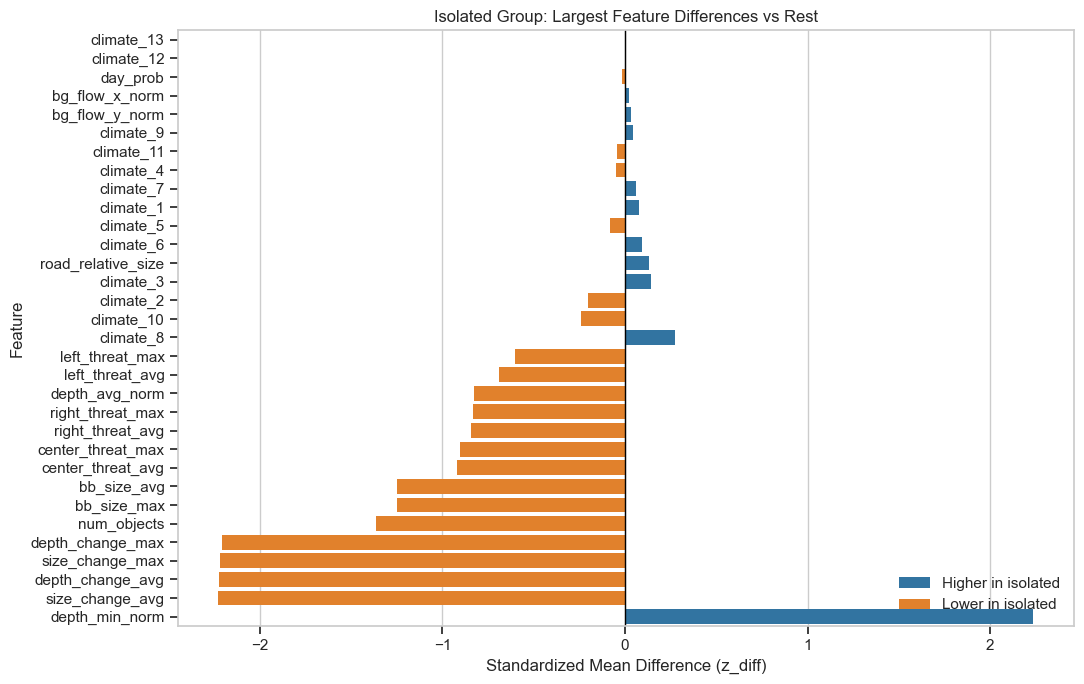

In [42]:
# Characterize isolated group from the previous diagnostic rule
iso_mask = (X_pca2[:, 0] < -2.0) & (X_pca2[:, 1] > -5.0)

base_cols = ["scenario", "ground_truth_risk", "true_ego_speed", "day_prob", "weather"]
sel_cols = list(dict.fromkeys(base_cols + feature_cols))

iso_df = df.loc[valid_target, sel_cols].copy().reset_index(drop=True)

iso_df["town"] = (
    iso_df["scenario"]
    .astype(str)
    .str.extract(r"(Town\d+)", expand=False)
    .str.upper()
    .fillna("UNKNOWN")
)
iso_df["weather_str"] = iso_df["weather"].astype(str)

iso_size = int(iso_mask.sum())
all_size = len(iso_mask)
print(f"Isolated rule: PC1 < -2 and PC2 > -5")
print(f"Rows in isolated group: {iso_size:,} / {all_size:,} ({100.0 * iso_size / all_size:.2f}%)")

# Core metric comparison against the rest
metrics = ["ground_truth_risk", "true_ego_speed", "day_prob"]
metric_cmp = pd.DataFrame({
    "isolated_mean": iso_df.loc[iso_mask, metrics].mean(numeric_only=True),
    "rest_mean": iso_df.loc[~iso_mask, metrics].mean(numeric_only=True),
})
metric_cmp["delta"] = metric_cmp["isolated_mean"] - metric_cmp["rest_mean"]
print("\nMetric comparison (isolated vs rest):")
display(metric_cmp)

# Biggest feature differences (standardized mean difference)
feature_mean_iso = iso_df.loc[iso_mask, feature_cols].mean(numeric_only=True)
feature_mean_rest = iso_df.loc[~iso_mask, feature_cols].mean(numeric_only=True)
feature_std_all = iso_df[feature_cols].std(numeric_only=True).replace(0, np.nan)

feature_diff = pd.DataFrame({
    "isolated_mean": feature_mean_iso,
    "rest_mean": feature_mean_rest,
})
feature_diff["delta"] = feature_diff["isolated_mean"] - feature_diff["rest_mean"]
feature_diff["z_diff"] = (feature_diff["delta"] / feature_std_all).fillna(0.0)
feature_diff["abs_z_diff"] = feature_diff["z_diff"].abs()
feature_diff = feature_diff.sort_values("abs_z_diff", ascending=False)

print("\nTop 12 strongest feature differences (by |z_diff|):")
display(feature_diff.head(12))

# Composition summaries
print("\nTop towns in isolated group:")
print(iso_df.loc[iso_mask, "town"].value_counts().head(10))

print("\nTop scenarios in isolated group:")
print(iso_df.loc[iso_mask, "scenario"].value_counts().head(12))

print("\nTop weather labels in isolated group:")
print(iso_df.loc[iso_mask, "weather_str"].value_counts().head(10))

# Visual: strongest differences in the isolated group
plot_diff = feature_diff.head(32).iloc[::-1].copy()
plot_diff["direction"] = np.where(plot_diff["z_diff"] >= 0, "Higher in isolated", "Lower in isolated")

plt.figure(figsize=(11, 7))
sns.barplot(data=plot_diff, x="z_diff", y=plot_diff.index, hue="direction", dodge=False)
plt.axvline(0.0, color="black", linewidth=1)
plt.xlabel("Standardized Mean Difference (z_diff)")
plt.ylabel("Feature")
plt.title("Isolated Group: Largest Feature Differences vs Rest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Clustering Analysis (n Clusters)
Clustering on standardized feature vectors, with per-cluster characterization and strongest distinguishing features.

In [43]:
from sklearn.cluster import MiniBatchKMeans

n_clusters = 6  # Adjust as needed

X_scaled_local = X_scaled if "X_scaled" in globals() else StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(df.loc[valid_target, feature_cols]))

cluster_model = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=4096, n_init=10)
cluster_labels = cluster_model.fit_predict(X_scaled_local)
print(f"Clustering done. n_clusters={n_clusters}, inertia={cluster_model.inertia_:.2f}")

Clustering done. n_clusters=6, inertia=5865041.38


### Cluster Characterization

In [44]:
base_cols = ["scenario", "ground_truth_risk", "true_ego_speed", "day_prob", "weather"]
sel_cols = list(dict.fromkeys(base_cols + feature_cols))

cluster_df = df.loc[valid_target, sel_cols].copy().reset_index(drop=True)
cluster_df["cluster"] = cluster_labels
cluster_df["town"] = cluster_df["scenario"].astype(str).str.extract(r"(Town\d+)", expand=False).str.upper().fillna("UNKNOWN")
cluster_df["weather_str"] = cluster_df["weather"].astype(str)

cluster_sizes = cluster_df["cluster"].value_counts().sort_index().rename("rows").to_frame()
cluster_sizes["pct"] = (100.0 * cluster_sizes["rows"] / len(cluster_df)).round(2)
print("Cluster sizes:")
display(cluster_sizes)

print("\nCluster mean metrics:")
display(cluster_df.groupby("cluster")[["ground_truth_risk", "true_ego_speed", "day_prob"]].mean(numeric_only=True))

global_mean = cluster_df[feature_cols].mean(numeric_only=True)
global_std = cluster_df[feature_cols].std(numeric_only=True).replace(0, np.nan)

diff_rows = []
for c in sorted(cluster_df["cluster"].unique()):
    c_mean = cluster_df.loc[cluster_df["cluster"] == c, feature_cols].mean(numeric_only=True)
    z_diff = ((c_mean - global_mean) / global_std).fillna(0.0)
    for feat in z_diff.abs().sort_values(ascending=False).head(8).index:
        diff_rows.append({"cluster": int(c), "feature": feat, "z_diff": float(z_diff[feat]), "abs_z_diff": abs(float(z_diff[feat]))})

cluster_diff = pd.DataFrame(diff_rows).sort_values(["cluster", "abs_z_diff"], ascending=[True, False])
print("\nTop distinguishing features per cluster:")
display(cluster_diff)

# Top towns and scenarios per cluster
for label, col in [("towns", "town"), ("scenarios", "scenario")]:
    top = (
        cluster_df.groupby("cluster")[col].value_counts(normalize=True).mul(100).rename("pct")
        .reset_index().sort_values(["cluster", "pct"], ascending=[True, False])
        .groupby("cluster").head(3)
    )
    print(f"\nTop {label} per cluster:")
    display(top)

Cluster sizes:


,rows,pct
cluster,,
0,29858,9.87
1,24059,7.96
2,104990,34.72
3,53669,17.75
4,35988,11.90
5,53836,17.80



Cluster mean metrics:


,ground_truth_risk,true_ego_speed,day_prob
cluster,,,
0,3.370430,9.597996,0.631288
1,2.720406,3.664097,0.995580
2,3.429027,4.577831,0.952240
3,3.525104,10.851385,0.926627
4,3.099014,3.429041,0.235703
5,2.438050,0.993301,0.900825



Top distinguishing features per cluster:


,cluster,feature,z_diff,abs_z_diff
0,0,depth_min_norm,1.617992,1.617992
1,0,size_change_avg,-1.611041,1.611041
2,0,depth_change_avg,-1.608159,1.608159
3,0,size_change_max,-1.603367,1.603367
4,0,depth_change_max,-1.598568,1.598568
5,0,num_objects,-0.978965,0.978965
6,0,bb_size_max,-0.904317,0.904317
7,0,bb_size_avg,-0.903942,0.903942
8,1,climate_11,2.528516,2.528516
9,1,size_change_avg,0.618795,0.618795



Top towns per cluster:


,cluster,town,pct
0,0,TOWN04,28.123116
1,0,TOWN03,18.018621
2,0,TOWN01,15.242146
6,1,TOWN03,29.639636
7,1,TOWN01,24.859720
8,1,TOWN02,23.725009
12,2,TOWN01,28.369369
13,2,TOWN02,22.583103
14,2,TOWN04,19.000857
18,3,TOWN04,37.846802



Top scenarios per cluster:


,cluster,scenario,pct
0,0,15A_ClearNoon_Town04_HighVol_NoFog_Night,7.512225
1,0,15D_HardRainNoon_Town04_LowVol_NoFog_Night,7.261036
2,0,21D_HardRainNoon_Town10HD_LowVol_NoFog_Night,6.644785
65,1,11A_WetCloudySunset_Town03_HighVol,12.419469
66,1,04D_WetCloudyNoon_Town02_LowVol,12.190864
67,1,04B_WetCloudyNoon_Town01_LowVol,10.844175
94,2,13A_MidRainSunset_Town01_HighVol,3.008858
95,2,14C_HardRainSunset_Town01_HighVol,2.884084
96,2,07A_HardRainNoon_Town01_HighVol,2.752643
173,3,06D_MidRainyNoon_Town04_LowVol,4.643276


### Cluster Visualization — PCA View + Feature Heatmap

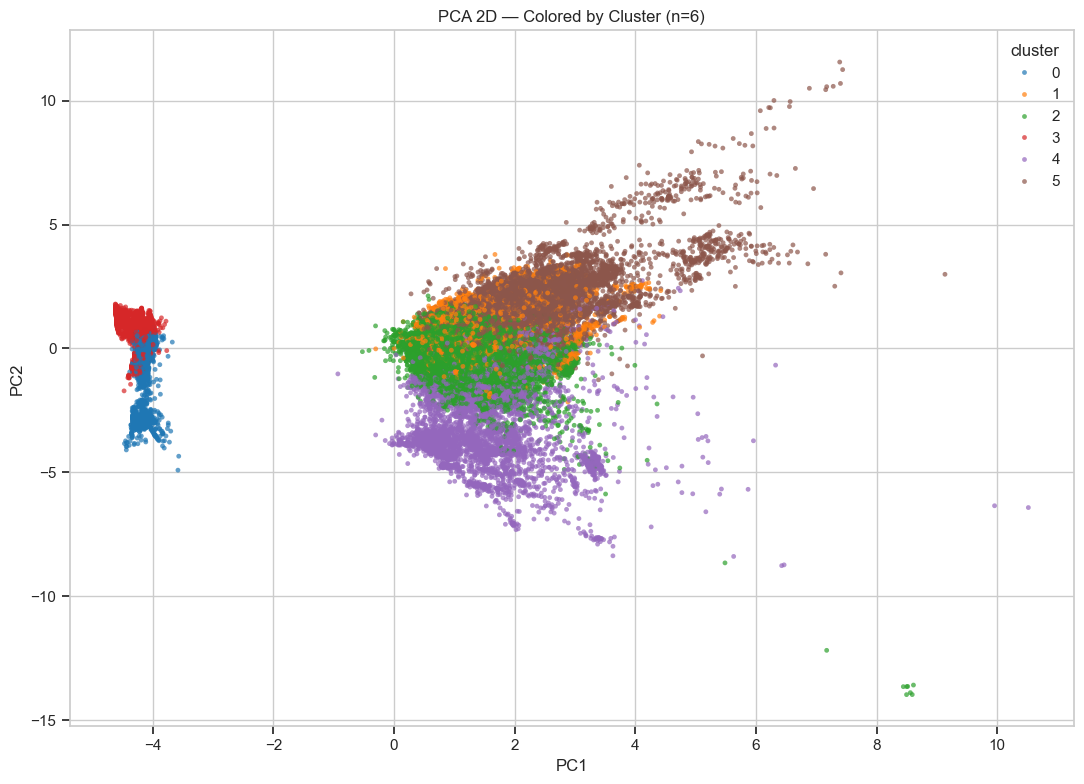

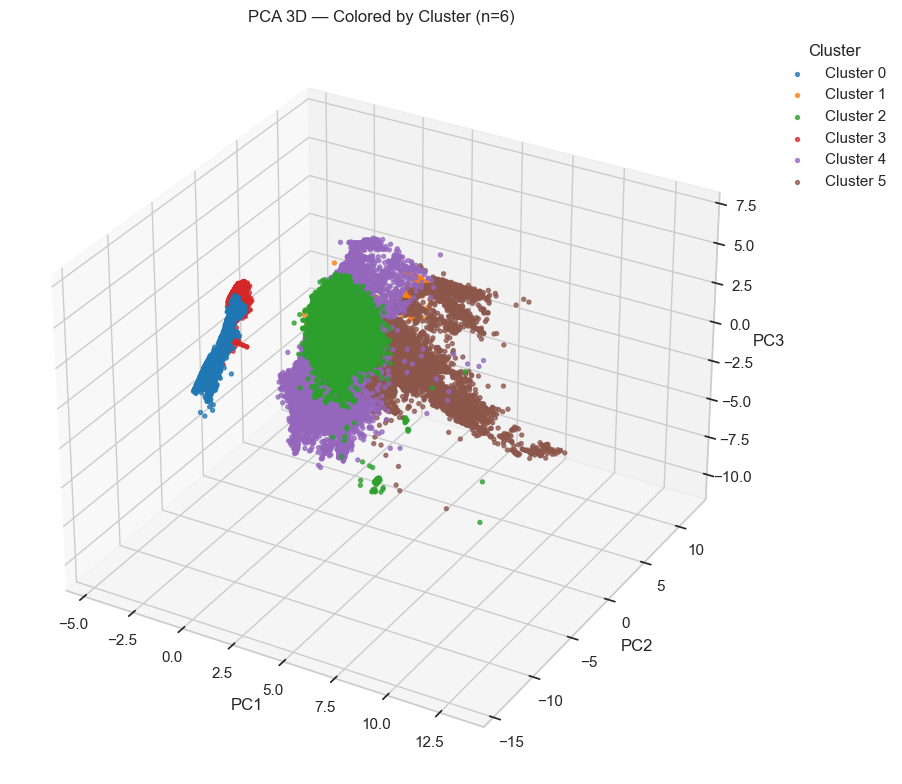

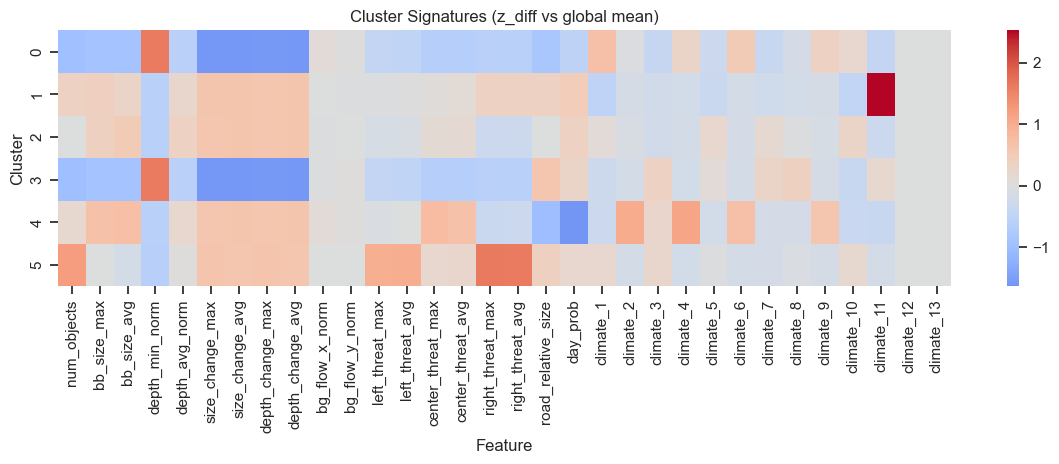

In [47]:
plot_cluster = pd.DataFrame({"PC1": X_pca2[:, 0], "PC2": X_pca2[:, 1], "cluster": cluster_labels})
if len(plot_cluster) > 50000:
    plot_cluster = plot_cluster.sample(50000, random_state=42)

plt.figure(figsize=(11, 8))
sns.scatterplot(data=plot_cluster, x="PC1", y="PC2", hue="cluster", palette="tab10", s=12, alpha=0.70, linewidth=0)
plt.title(f"PCA 2D — Colored by Cluster (n={n_clusters})")
plt.tight_layout()
plt.show()

# 3d PCA
fig3d = plt.figure(figsize=(11, 8))
ax3d = fig3d.add_subplot(111, projection="3d")
for c in sorted(cluster_df["cluster"].unique()):
    mask = cluster_labels == c
    if not np.any(mask):
        continue
    ax3d.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2], label=f"Cluster {c}", s=8, alpha=0.75)
ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
ax3d.set_title(f"PCA 3D — Colored by Cluster (n={n_clusters})")
ax3d.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Heatmap of all features per cluster
heat_features = feature_cols

heat_rows = []
for c in sorted(cluster_df["cluster"].unique()):
    c_mean = cluster_df.loc[cluster_df["cluster"] == c, feature_cols].mean(numeric_only=True)
    z_diff = ((c_mean - global_mean) / global_std).fillna(0.0)
    heat_rows.append(z_diff.loc[heat_features].rename(c))

heat_df = pd.DataFrame(heat_rows)

plt.figure(figsize=(max(12, 0.35 * len(heat_features)), 4.8))
sns.heatmap(heat_df, cmap="coolwarm", center=0.0, annot=False)
plt.title("Cluster Signatures (z_diff vs global mean)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()